# Regression Analysis

This notebook uses the previously cleaned datasets for gas and electricity usage and provides a regression analysis of the data.

Available DataFrames:
- `gas_monthly_usage`
- `electric_monthly_usage`

This version keeps more of the original wording and narrative, while cleaning the code, improving the organization, and making the regression comparisons easier to follow.


### Accessing the dataset

First, equivalently to how data was fetched in the EDA notebook, fetch the data for gas usage and electricity usage and save the data as dataframes. Also do a visual check of the imported data.


In [1]:

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "clean").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing data/clean.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "clean"

gas_monthly_usage = pd.read_csv(DATA_DIR / "gas_monthly_usage.csv")
electric_monthly_usage = pd.read_csv(DATA_DIR / "electric_monthly_usage.csv")

print("Gas dataset shape:", gas_monthly_usage.shape)
print("Electricity dataset shape:", electric_monthly_usage.shape)

gas_monthly_usage.head()


Gas dataset shape: (8412, 6)
Electricity dataset shape: (19656, 6)


,Property Name,Portfolio Manager ID,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-01-01,23839.31
1,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-02-01,18735.80
2,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-03-01,14082.81
3,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-04-01,11537.50
4,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-05-01,7784.48


### Additional Data cleaning

- Filter the dataframes to include only pertinent columns (features and the output variable)
- Drop rows with placeholder values for the gross floor area (i.e. where GFA = 1)
- Keep the month variable in a format that can be treated cleanly as a categorical variable later


In [2]:

gas_usage_for_regression = gas_monthly_usage[[
    "Gross Floor Area",
    "month",
    "Property Type - Self-Selected",
    "normalized_monthly_usage",
]].copy()

electricity_usage_for_regression = electric_monthly_usage[[
    "Gross Floor Area",
    "month",
    "Property Type - Self-Selected",
    "normalized_monthly_usage",
]].copy()

for name, df in {
    "gas": gas_usage_for_regression,
    "electricity": electricity_usage_for_regression,
}.items():
    df["month"] = pd.to_datetime(df["month"])
    df.dropna(
        subset=[
            "Gross Floor Area",
            "month",
            "Property Type - Self-Selected",
            "normalized_monthly_usage",
        ],
        inplace=True,
    )
    df = df[df["Gross Floor Area"] != 1]

    if name == "gas":
        gas_usage_for_regression = df.copy()
    else:
        electricity_usage_for_regression = df.copy()

print("Gas regression dataframe shape:", gas_usage_for_regression.shape)
print("Electricity regression dataframe shape:", electricity_usage_for_regression.shape)


Gas regression dataframe shape: (8052, 4)
Electricity regression dataframe shape: (13692, 4)


### Quick checks

Before running the models, do a quick check of the regression datasets to confirm that the property types and the basic GFA vs usage patterns look reasonable.


In [3]:

print("Gas property types:")
print(gas_usage_for_regression["Property Type - Self-Selected"].value_counts())

print("Electricity property types:")
print(electricity_usage_for_regression["Property Type - Self-Selected"].value_counts())


Gas property types:
Property Type - Self-Selected
Other-Public Services          2820
Recreation & Community         1824
Public Safety                  1452
Education & Social Services    1212
Administrative / Office         468
Transportation                  192
Utilities / Infrastructure       84
Name: count, dtype: int64
Electricity property types:
Property Type - Self-Selected
Other-Public Services          6084
Recreation & Community         2064
Transportation                 1800
Public Safety                  1512
Education & Social Services    1296
Administrative / Office         516
Utilities / Infrastructure      420
Name: count, dtype: int64


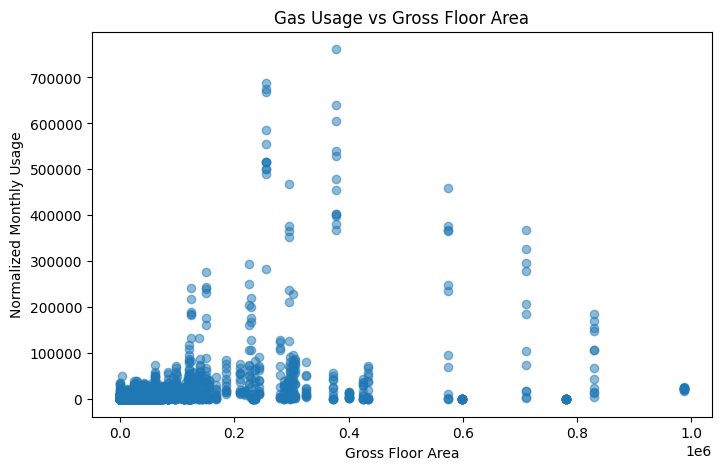

In [4]:

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    gas_usage_for_regression["Gross Floor Area"],
    gas_usage_for_regression["normalized_monthly_usage"],
    alpha=0.5,
)
ax.set_title("Gas Usage vs Gross Floor Area")
ax.set_xlabel("Gross Floor Area")
ax.set_ylabel("Normalized Monthly Usage")
plt.show()


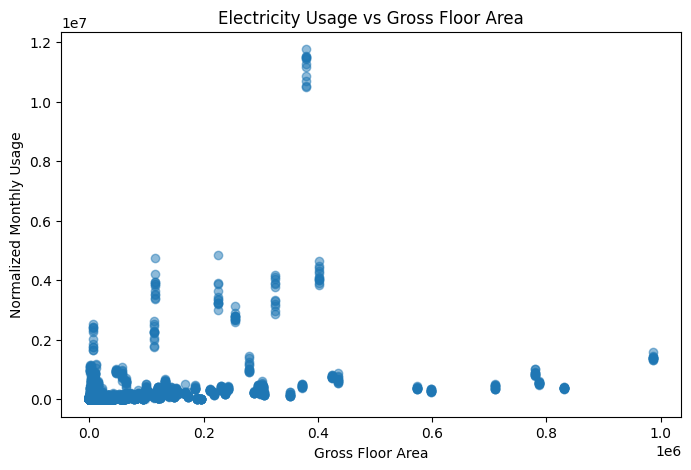

In [5]:

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    electricity_usage_for_regression["Gross Floor Area"],
    electricity_usage_for_regression["normalized_monthly_usage"],
    alpha=0.5,
)
ax.set_title("Electricity Usage vs Gross Floor Area")
ax.set_xlabel("Gross Floor Area")
ax.set_ylabel("Normalized Monthly Usage")
plt.show()


### Simple regression analysis only using GFA and monthly usage

First we conduct a simple regression analysis, utilizing the GFA (feature) and normalized monthly usage (output) variables alone. Based on the scatterplots from the EDA notebook, we expect this analysis to be somewhat unfulfilling, but it provides a useful baseline for later comparisons.


In [6]:

def fit_and_evaluate_linear_model(X, y, test_size=0.15, random_state=28):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        "model": model,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "mse": mse,
        "r2": r2,
    }


def prepare_base_features(df):
    X = df[["Gross Floor Area", "Property Type - Self-Selected", "month"]].copy()
    X["month"] = pd.to_datetime(X["month"]).dt.month_name()

    X_encoded = pd.get_dummies(
        X,
        columns=["Property Type - Self-Selected", "month"],
        drop_first=True,
        dtype=float,
    )
    return X_encoded


def add_gfa_property_type_interactions(X_encoded):
    X_interaction = X_encoded.copy()
    property_cols = [
        col for col in X_interaction.columns
        if col.startswith("Property Type - Self-Selected_")
    ]

    for col in property_cols:
        X_interaction[f"GFA_x_{col}"] = (
            X_interaction["Gross Floor Area"] * X_interaction[col]
        )

    return X_interaction


def model_summary_dataframe(feature_names, coefficients):
    return pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients,
    }).sort_values(by="Coefficient", key=abs, ascending=False)



## 5. Simple regression using GFA only

This model uses only Gross Floor Area as the predictor. It serves as a baseline for comparison.


In [7]:

X_gas_simple = gas_usage_for_regression[["Gross Floor Area"]]
y_gas = gas_usage_for_regression["normalized_monthly_usage"]

gas_simple_results = fit_and_evaluate_linear_model(X_gas_simple, y_gas)

print("Gas simple regression")
print("MSE:", gas_simple_results["mse"])
print("R2:", gas_simple_results["r2"])


Gas simple regression
MSE: 961501300.4589884
R2: 0.12603625410689945


In [8]:

X_electric_simple = electricity_usage_for_regression[["Gross Floor Area"]]
y_electric = electricity_usage_for_regression["normalized_monthly_usage"]

electric_simple_results = fit_and_evaluate_linear_model(X_electric_simple, y_electric)

print("Electricity simple regression")
print("MSE:", electric_simple_results["mse"])
print("R2:", electric_simple_results["r2"])


Electricity simple regression
MSE: 127643453458.39056
R2: 0.1442431625232411


Simple visual checks

A plot of actual vs predicted values helps show whether the simple regression is tracking the data well. If the points stray far from the diagonal, then GFA alone is not capturing enough of the variation in usage.


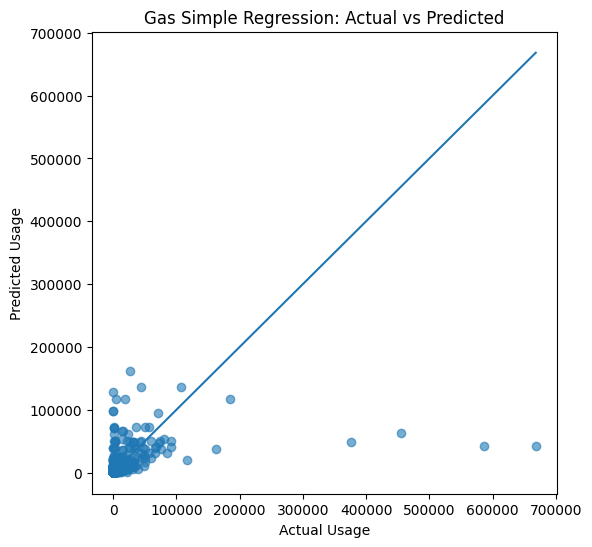

In [9]:

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(gas_simple_results["y_test"], gas_simple_results["y_pred"], alpha=0.6)
ax.plot(
    [gas_simple_results["y_test"].min(), gas_simple_results["y_test"].max()],
    [gas_simple_results["y_test"].min(), gas_simple_results["y_test"].max()],
)
ax.set_title("Gas Simple Regression: Actual vs Predicted")
ax.set_xlabel("Actual Usage")
ax.set_ylabel("Predicted Usage")
plt.show()


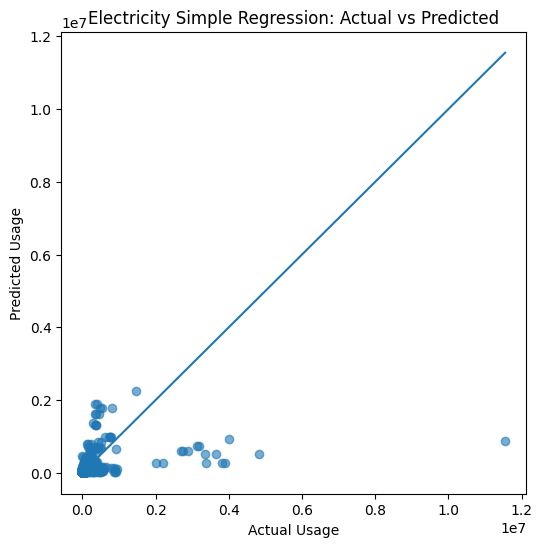

In [10]:

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(electric_simple_results["y_test"], electric_simple_results["y_pred"], alpha=0.6)
ax.plot(
    [electric_simple_results["y_test"].min(), electric_simple_results["y_test"].max()],
    [electric_simple_results["y_test"].min(), electric_simple_results["y_test"].max()],
)
ax.set_title("Electricity Simple Regression: Actual vs Predicted")
ax.set_xlabel("Actual Usage")
ax.set_ylabel("Predicted Usage")
plt.show()


### Regression analysis using GFA, property type and month

We now take a step further and conduct an analysis adding the property type and month as categorical variables. This lets the model account for both differences in building category and differences across the year.


In [11]:

X_gas_base = prepare_base_features(gas_usage_for_regression)
y_gas = gas_usage_for_regression["normalized_monthly_usage"]

gas_base_results = fit_and_evaluate_linear_model(X_gas_base, y_gas)
gas_base_coef_df = model_summary_dataframe(
    X_gas_base.columns,
    gas_base_results["model"].coef_,
)

print("Gas multivariable regression")
print("Intercept:", gas_base_results["model"].intercept_)
print("MSE:", gas_base_results["mse"])
print("R2:", gas_base_results["r2"])

gas_base_coef_df.head(20)


Gas multivariable regression
Intercept: -3347.946115943011
MSE: 773757662.6391093
R2: 0.2966872276399902


,Feature,Coefficient
6,Property Type - Self-Selected_Utilities / Infr...,154737.103591
5,Property Type - Self-Selected_Transportation,36442.356704
10,month_January,7049.685609
8,month_December,6748.789323
13,month_March,5328.128812
9,month_February,5268.341008
4,Property Type - Self-Selected_Recreation & Com...,4696.826279
2,Property Type - Self-Selected_Other-Public Ser...,4535.785454
17,month_September,-4043.807169
7,month_August,-3875.657563


In [12]:

X_electric_base = prepare_base_features(electricity_usage_for_regression)
y_electric = electricity_usage_for_regression["normalized_monthly_usage"]

electric_base_results = fit_and_evaluate_linear_model(X_electric_base, y_electric)
electric_base_coef_df = model_summary_dataframe(
    X_electric_base.columns,
    electric_base_results["model"].coef_,
)

print("Electricity multivariable regression")
print("Intercept:", electric_base_results["model"].intercept_)
print("MSE:", electric_base_results["mse"])
print("R2:", electric_base_results["r2"])

electric_base_coef_df.head(20)


Electricity multivariable regression
Intercept: -110911.3807461277
MSE: 100776762730.19455
R2: 0.3243648504601939


,Feature,Coefficient
6,Property Type - Self-Selected_Utilities / Infr...,1.210349e+06
2,Property Type - Self-Selected_Other-Public Ser...,1.056697e+05
4,Property Type - Self-Selected_Recreation & Com...,8.754681e+04
1,Property Type - Self-Selected_Education & Soci...,8.574975e+04
3,Property Type - Self-Selected_Public Safety,8.351400e+04
5,Property Type - Self-Selected_Transportation,5.222770e+04
10,month_January,1.311502e+04
11,month_July,7.852084e+03
16,month_October,7.018423e+03
13,month_March,6.536544e+03


Visualizing the role of Property Type

These plots are useful for checking whether some property types appear to cluster differently. This helps motivate the interaction analysis later, especially if the relationship between GFA and usage seems to vary by property type.


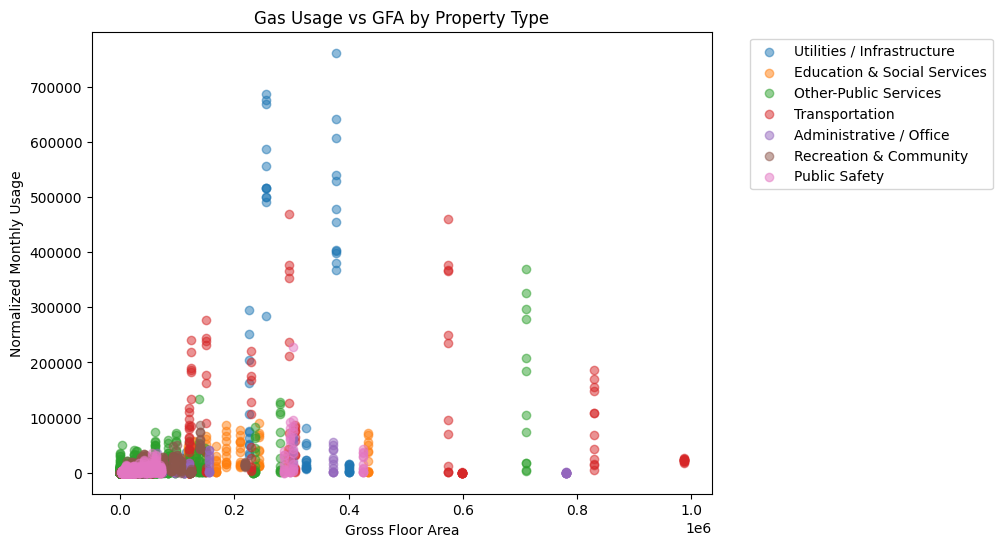

In [21]:

fig, ax = plt.subplots(figsize=(8, 6))
for property_type in gas_usage_for_regression["Property Type - Self-Selected"].dropna().unique():
    subset = gas_usage_for_regression[
        gas_usage_for_regression["Property Type - Self-Selected"] == property_type
    ]
    ax.scatter(
        subset["Gross Floor Area"],
        subset["normalized_monthly_usage"],
        alpha=0.5,
        label=property_type,
    )

ax.set_title("Gas Usage vs GFA by Property Type")
ax.set_xlabel("Gross Floor Area")
ax.set_ylabel("Normalized Monthly Usage")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


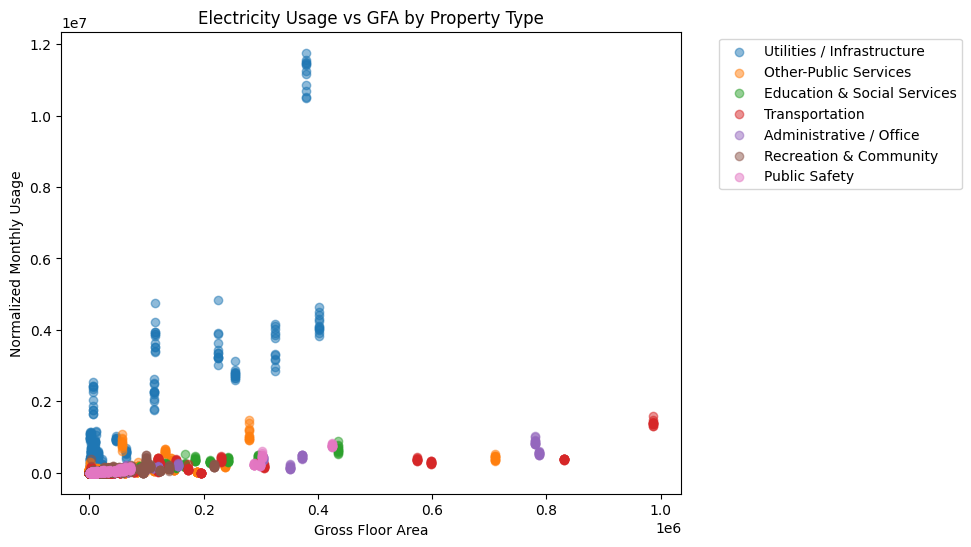

In [22]:

fig, ax = plt.subplots(figsize=(8, 6))
for property_type in electricity_usage_for_regression["Property Type - Self-Selected"].dropna().unique():
    subset = electricity_usage_for_regression[
        electricity_usage_for_regression["Property Type - Self-Selected"] == property_type
    ]
    ax.scatter(
        subset["Gross Floor Area"],
        subset["normalized_monthly_usage"],
        alpha=0.5,
        label=property_type,
    )

ax.set_title("Electricity Usage vs GFA by Property Type")
ax.set_xlabel("Gross Floor Area")
ax.set_ylabel("Normalized Monthly Usage")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


### Regression Using GFA, Property Type, Month, and an Interaction Term

Now we consider an interaction term in the model including all variables. We use `GFA × Property Type` as the interaction term, since there may be a relationship between building size and the type of property. This allows different property types to have different GFA slopes rather than forcing one common slope across all of them.


In [15]:

X_gas_interaction = add_gfa_property_type_interactions(X_gas_base)
y_gas = gas_usage_for_regression["normalized_monthly_usage"]

gas_interaction_results = fit_and_evaluate_linear_model(X_gas_interaction, y_gas)
gas_interaction_coef_df = model_summary_dataframe(
    X_gas_interaction.columns,
    gas_interaction_results["model"].coef_,
)

print("Gas interaction regression")
print("Intercept:", gas_interaction_results["model"].intercept_)
print("MSE:", gas_interaction_results["mse"])
print("R2:", gas_interaction_results["r2"])

gas_interaction_coef_df.head(30)


Gas interaction regression
Intercept: 3227.1727111705595
MSE: 783179405.6953632
R2: 0.288123264335567


,Feature,Coefficient
5,Property Type - Self-Selected_Transportation,45502.152998
6,Property Type - Self-Selected_Utilities / Infr...,10690.701851
10,month_January,6916.130191
8,month_December,6712.023401
13,month_March,5362.990303
9,month_February,5028.076667
17,month_September,-4259.740177
11,month_July,-3973.215760
7,month_August,-3954.897672
2,Property Type - Self-Selected_Other-Public Ser...,-3874.894236


In [16]:

X_electric_interaction = add_gfa_property_type_interactions(X_electric_base)
y_electric = electricity_usage_for_regression["normalized_monthly_usage"]

electric_interaction_results = fit_and_evaluate_linear_model(X_electric_interaction, y_electric)
electric_interaction_coef_df = model_summary_dataframe(
    X_electric_interaction.columns,
    electric_interaction_results["model"].coef_,
)

print("Electricity interaction regression")
print("Intercept:", electric_interaction_results["model"].intercept_)
print("MSE:", electric_interaction_results["mse"])
print("R2:", electric_interaction_results["r2"])

electric_interaction_coef_df.head(30)


Electricity interaction regression
Intercept: 5744.714572810539
MSE: 35570637441.11925
R2: 0.7615246581089454


,Feature,Coefficient
6,Property Type - Self-Selected_Utilities / Infr...,285738.707631
10,month_January,14015.353119
3,Property Type - Self-Selected_Public Safety,-12849.391456
5,Property Type - Self-Selected_Transportation,-11929.689048
1,Property Type - Self-Selected_Education & Soci...,-10453.226059
9,month_February,5962.018389
4,Property Type - Self-Selected_Recreation & Com...,-4735.653192
13,month_March,4729.054781
8,month_December,4712.624983
16,month_October,3275.771395


### Model comparison tables

These tables summarize the performance of the three model families for gas and electricity:

- Simple regression using GFA only
- A multivariable model using GFA, property type, and month
- A multivariable model including the `GFA × Property Type` interaction


In [17]:

gas_model_comparison = pd.DataFrame({
    "Model": [
        "Simple: GFA only",
        "Base: GFA + Property Type + Month",
        "Interaction: Base + GFA × Property Type",
    ],
    "MSE": [
        gas_simple_results["mse"],
        gas_base_results["mse"],
        gas_interaction_results["mse"],
    ],
    "R2": [
        gas_simple_results["r2"],
        gas_base_results["r2"],
        gas_interaction_results["r2"],
    ],
})

gas_model_comparison


,Model,MSE,R2
0,Simple: GFA only,9.615013e+08,0.126036
1,Base: GFA + Property Type + Month,7.737577e+08,0.296687
2,Interaction: Base + GFA × Property Type,7.831794e+08,0.288123


In [18]:

electric_model_comparison = pd.DataFrame({
    "Model": [
        "Simple: GFA only",
        "Base: GFA + Property Type + Month",
        "Interaction: Base + GFA × Property Type",
    ],
    "MSE": [
        electric_simple_results["mse"],
        electric_base_results["mse"],
        electric_interaction_results["mse"],
    ],
    "R2": [
        electric_simple_results["r2"],
        electric_base_results["r2"],
        electric_interaction_results["r2"],
    ],
})

electric_model_comparison


,Model,MSE,R2
0,Simple: GFA only,1.276435e+11,0.144243
1,Base: GFA + Property Type + Month,1.007768e+11,0.324365
2,Interaction: Base + GFA × Property Type,3.557064e+10,0.761525


### Interpretation notes

The comparison tables and coefficient tables can be used to support conclusions such as:

- A low R² in the simple model suggests that GFA alone does not explain enough of the variation in energy usage
- A higher R² in the multivariable model suggests that property type and month add meaningful predictive information
- A large improvement after adding `GFA × Property Type` suggests that the relationship between building size and usage differs across property types

This is especially important for electricity usage, where the interaction model may reveal that one common GFA slope is too simplistic.


### Optional next steps

Further extensions could include:

- Adding `GFA × Month` interaction terms
- Investigating outliers more formally using IQR or z-score methods
- Comparing train and test scores side by side
- Trying regularized models such as Ridge or Lasso if the interaction model becomes unstable


### Optional Analysis Using LASSO

Consider using LASSO to reduce the sheer number of variables in both models (USAGE ~ GFA + MONTH + PROPERTY_TYPE + GFA*PROPERTY_TYPE).

#### Gas Usage

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Select predictors and target
X_gas = gas_usage_for_regression[['Gross Floor Area', 'Property Type - Self-Selected', 'month']].copy()
y_gas = gas_usage_for_regression['normalized_monthly_usage']

# Convert month to month name
X_gas['month'] = pd.to_datetime(X_gas['month']).dt.month_name()

# One-hot encode categorical variables
X_gas_encoded = pd.get_dummies(
    X_gas,
    columns=['Property Type - Self-Selected', 'month'],
    drop_first=True,
    dtype=float
)

# Identify dummy columns
property_cols = [col for col in X_gas_encoded.columns if 'Property Type - Self-Selected_' in col]

# Add interaction term
# GFA × Property Type
for col in property_cols:
    X_gas_encoded[f'GFA_x_{col}'] = (
        X_gas_encoded['Gross Floor Area'] * X_gas_encoded[col]
    )

# Train/test split
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_gas_encoded, y_gas, test_size=0.15, random_state=28
)

# Lasso pipeline
gas_lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, random_state=28, max_iter=10000))
])

# Train model
gas_lasso_model.fit(Xg_train, yg_train)

# Predict
yg_pred_lasso = gas_lasso_model.predict(Xg_test)

# Metrics
print("GAS LASSO MODEL RESULTS")
print("Best alpha:", gas_lasso_model.named_steps['lasso'].alpha_)
print("MSE:", mean_squared_error(yg_test, yg_pred_lasso))
print("R2:", r2_score(yg_test, yg_pred_lasso))

# Coefficients
lasso_coefs = gas_lasso_model.named_steps['lasso'].coef_

gas_lasso_coef_df = pd.DataFrame({
    'Feature': X_gas_encoded.columns,
    'Coefficient': lasso_coefs
})

# Keep only non-zero coefficients selected by Lasso
gas_lasso_selected_df = gas_lasso_coef_df[
    gas_lasso_coef_df['Coefficient'] != 0
].sort_values(by='Coefficient', key=abs, ascending=False)

print("\nSelected Gas Features by Lasso:")
print(gas_lasso_selected_df)

print("\nNumber of selected features:", len(gas_lasso_selected_df))
print("Number of removed features:", (gas_lasso_coef_df['Coefficient'] == 0).sum())

GAS LASSO MODEL RESULTS
Best alpha: 23.382906778848373
MSE: 782641335.1679081
R2: 0.28861234753649956

Selected Gas Features by Lasso:
                                              Feature   Coefficient
23  GFA_x_Property Type - Self-Selected_Utilities ...  17532.658312
5        Property Type - Self-Selected_Transportation   7107.129319
19  GFA_x_Property Type - Self-Selected_Other-Publ...   6232.119236
18  GFA_x_Property Type - Self-Selected_Education ...   2393.629013
21  GFA_x_Property Type - Self-Selected_Recreation...   2065.057131
0                                    Gross Floor Area   2013.268350
10                                      month_January   1909.099030
8                                      month_December   1868.084561
20  GFA_x_Property Type - Self-Selected_Public Safety   1743.684936
22  GFA_x_Property Type - Self-Selected_Transporta...   1533.717771
13                                        month_March   1486.287222
9                                      month_Febr

No features were removed, consequently there is nothing of interest here.

#### Electricity Usage

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Select predictors and target
X_electric = electricity_usage_for_regression[['Gross Floor Area', 'Property Type - Self-Selected', 'month']].copy()
y_electric = electricity_usage_for_regression['normalized_monthly_usage']

# Convert month to month name
X_electric['month'] = pd.to_datetime(X_electric['month']).dt.month_name()

# One-hot encode categorical variables
X_electric_encoded = pd.get_dummies(
    X_electric,
    columns=['Property Type - Self-Selected', 'month'],
    drop_first=True,
    dtype=float
)

# Identify dummy columns
property_cols = [col for col in X_electric_encoded.columns if 'Property Type - Self-Selected_' in col]

# Add interaction term
# GFA × Property Type
for col in property_cols:
    X_electric_encoded[f'GFA_x_{col}'] = (
        X_electric_encoded['Gross Floor Area'] * X_electric_encoded[col]
    )

# Train/test split
Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X_electric_encoded, y_electric, test_size=0.15, random_state=28
)

# Lasso pipeline
electric_lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, random_state=28, max_iter=10000))
])

# Train model
electric_lasso_model.fit(Xe_train, ye_train)

# Predict
ye_pred_lasso = electric_lasso_model.predict(Xe_test)

# Metrics
print("ELECTRIC LASSO MODEL RESULTS")
print("Best alpha:", electric_lasso_model.named_steps['lasso'].alpha_)
print("MSE:", mean_squared_error(ye_test, ye_pred_lasso))
print("R2:", r2_score(ye_test, ye_pred_lasso))

# Coefficients
lasso_coefs = electric_lasso_model.named_steps['lasso'].coef_

electric_lasso_coef_df = pd.DataFrame({
    'Feature': X_electric_encoded.columns,
    'Coefficient': lasso_coefs
})

# Keep only non-zero coefficients selected by Lasso
electric_lasso_selected_df = electric_lasso_coef_df[
    electric_lasso_coef_df['Coefficient'] != 0
].sort_values(by='Coefficient', key=abs, ascending=False)

print("\nSelected Electric Features by Lasso:")
print(electric_lasso_selected_df)

print("\nNumber of selected features:", len(electric_lasso_selected_df))
print("Number of removed features:", (electric_lasso_coef_df['Coefficient'] == 0).sum())

ELECTRIC LASSO MODEL RESULTS
Best alpha: 1733.655507851629
MSE: 35384672553.514046
R2: 0.7627714178900934

Selected Electric Features by Lasso:
                                              Feature    Coefficient
23  GFA_x_Property Type - Self-Selected_Utilities ...  331341.964288
0                                    Gross Floor Area   70356.564735
6   Property Type - Self-Selected_Utilities / Infr...   48132.064410
18  GFA_x_Property Type - Self-Selected_Education ...   10326.597701
20  GFA_x_Property Type - Self-Selected_Public Safety    5337.476993
19  GFA_x_Property Type - Self-Selected_Other-Publ...    4921.193366
21  GFA_x_Property Type - Self-Selected_Recreation...    2803.673453
5        Property Type - Self-Selected_Transportation   -1918.809955
10                                      month_January    1505.323335
3         Property Type - Self-Selected_Public Safety    -621.144613
2   Property Type - Self-Selected_Other-Public Ser...      32.013187

Number of selected features

13 features were removed, leaving 11 features remaining to describe the model. This is a significant improvement,  considering R2 remains approximately the same ~0.76.